# Problem 1 - Variational Auto-Encoder (VAE)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/15R0hzDUst6-tNFmtRxZYNKoTMWQqTaZv)


Variational Auto-Encoders (VAEs) are a widely used class of generative models. They are simple to implement and, in contrast to other generative model classes like Generative Adversarial Networks (GANs, see Problem 2), they optimize an explicit maximum likelihood objective to train the model. Finally, their architecture makes them well-suited for unsupervised representation learning, i.e. learning low-dimensional representations of high-dimenionsal inputs, like images, with only self-supervised objectives (data reconstruction in the case of VAEs).

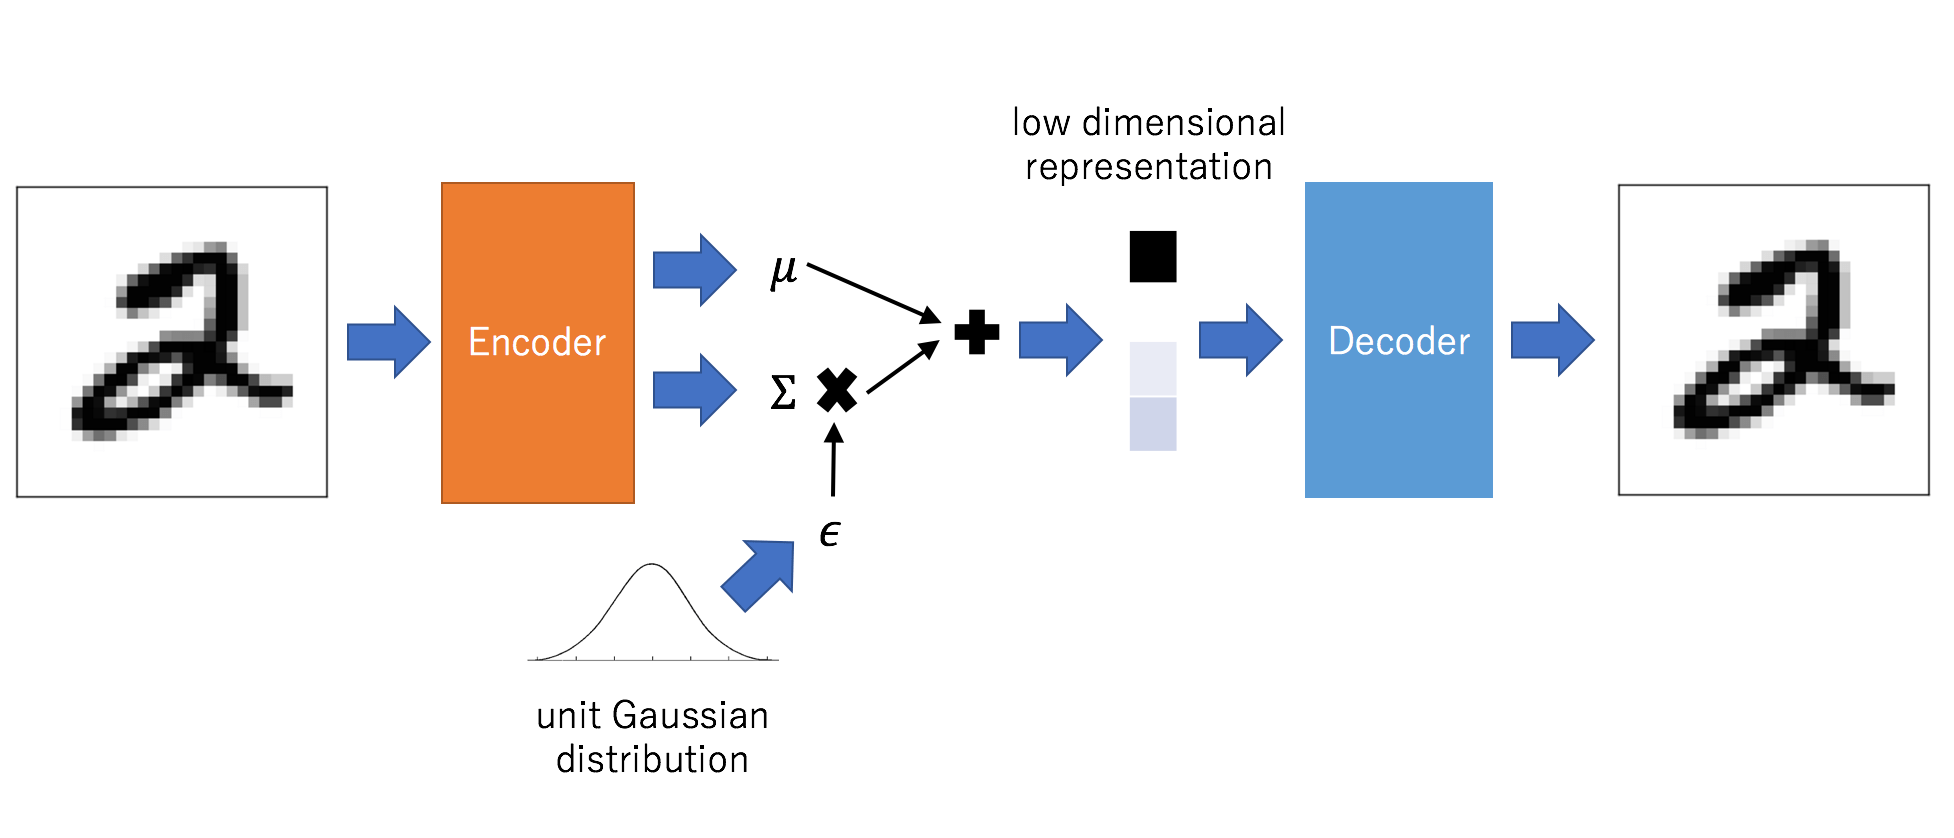
*(image source: https://mlexplained.com/2017/12/28/an-intuitive-explanation-of-variational-autoencoders-vaes-part-1)*

**By working on this problem you will learn and practice the following steps:**
1. Set up a data loading pipeline in PyTorch.
2. Implement, train and visualize an auto-encoder architecture.
3. Extend your implementation to a variational auto-encoder.
4. Learn how to tune the critical beta parameter of your VAE.
5. Inspect the learned representation of your VAE.


**Note**: For faster training of the models in this assignment you can use Colab with enabled GPU support. In Colab, navigate to "Runtime" --> "Change Runtime Type" and set the "Hardware Accelerator" to "GPU".

# 1. MNIST Dataset

We will perform all experiments for this problem using the [MNIST dataset](http://yann.lecun.com/exdb/mnist/), a standard dataset of handwritten digits. The main benefits of this dataset are that it is small and relatively easy to model. It therefore allows for quick experimentation and serves as initial test bed in many papers.

Another benefit is that it is so widely used that PyTorch even provides functionality to automatically download it.

Let's start by downloading the data and visualizing some samples.

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
import torch
import torchvision

# this will automatically download the MNIST training set
mnist_train = torchvision.datasets.MNIST(root='./data',
                                         train=True,
                                         download=True,
                                         transform=torchvision.transforms.ToTensor())
print("\n Download complete! Downloaded {} training examples!".format(len(mnist_train)))


 Download complete! Downloaded 60000 training examples!


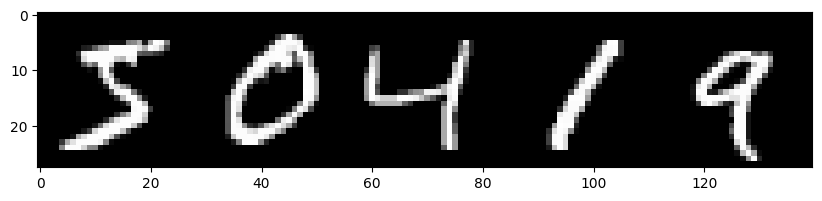

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Let's display some of the training samples.
sample_images = []
mnist_it = iter(mnist_train)  # create simple iterator, later we will use proper DataLoader
for _ in range(5):
  sample = next(mnist_it)     # samples a tuple (image, label)
  sample_images.append(sample[0][0].data.cpu().numpy())

fig = plt.figure(figsize = (10, 50))
ax1 = plt.subplot(111)
ax1.imshow(np.concatenate(sample_images, axis=1), cmap='gray')
plt.show()


# 2. Auto-Encoder

Before implementing the full VAE, we will first implement an **auto-encoder architecture**. Auto-encoders feature the same encoder-decoder architecture as VAEs and therefore also learn a low-dimensional representation of the input data without supervision. In contrast to VAEs they are **fully deterministic** models and do not employ variational inference for optimization.

The **architecture** is very simple: we will encode the input image into a low-dimensional representation using a convolutional network with strided convolutions that reduce the image resolution in every layer. This results in a low-dimensional representation of the input image. This representation will get decoded back into the dimensionality of the input image using a convolutional decoder network that mirrors the architecture of the encoder. It employs transposed convolutions to increase the resolution of its input in every layer. The whole model is trained by **minimizing a reconstruction loss** between the input and the decoded image.

Intuitively, the **auto-encoder needs to compress the information contained in the input image** into a much lower dimensional representation (e.g. 28x28=784px vs. 64 embedding dimensions for our MNIST model). This is possible since the information captured in the pixels is *highly redundant*. E.g. encoding an MNIST image requires <4 bits to encode which of the 10 possible digits is displayed and a few additional bits to capture information about shape and orientation. This is much less than the $255^{28\cdot 28}$ bits of information that could be theoretically captured in the input image.

Learning such a **compressed representation can make downstream task learning easier**. For example, learning to add two numbers based on the inferred digits is much easier than performing the task based on two piles of pixel values that depict the digits.

In the following, we will first define the architecture of encoder and decoder and then train the auto-encoder model.

## Defining the Auto-Encoder Architecture [6pt]

In [7]:
import torch.nn as nn

# Let's define encoder and decoder networks
#####################################################################
# Encoder Architecture:                                             #
#   - Conv2d, hidden units: 48, output resolution: 13x13, kernel: 4 #
#   - LeakyReLU                                                     #
#   - Conv2d, hidden units: 96, output resolution: 6x6, kernel: 4   #
#   - BatchNorm2d                                                   #
#   - LeakyReLU                                                     #
#   - Conv2d, hidden units: 192, output resolution: 2x2, kernel: 3  #
#   - BatchNorm2d                                                   #
#   - LeakyReLU                                                     #
#   - Conv2d, hidden units: 384, output resolution: 1x1, kernel: 3  #
#   - BatchNorm2d                                                   #
#   - LeakyReLU                                                     #
#   - Flatten                                                       #
#   - Linear, output units: nz (= representation dimensionality)    #
#####################################################################

class Encoder(nn.Module):
  def __init__(self, nz):
    super().__init__()
    ################################# TODO #########################################
    # Create the network architecture using a nn.Sequential module wrapper.        #
    # All convolutional layers should also learn a bias.                           #
    # HINT: use the given information to compute stride and padding                #
    #       for each convolutional layer. Verify the shapes of intermediate layers #
    #       by running partial networks (with the next cell) and visualizing the   #
    #       output shapes.                                                         #
    ################################################################################
    self.net = nn.Sequential(
        # add your network layers here
        nn.Conv2d(in_channels=1, out_channels=48, kernel_size=4, stride=2, padding=0, bias=True),
        nn.LeakyReLU(),
        
        nn.Conv2d(in_channels=48, out_channels=96, kernel_size=4, stride=2, padding=1, bias=True),
        nn.BatchNorm2d(num_features=96),
        nn.LeakyReLU(),
        
        nn.Conv2d(in_channels=96, out_channels=192, kernel_size=3, stride=2, padding=0, bias=True),
        nn.BatchNorm2d(num_features=192),
        nn.LeakyReLU(),
        
        nn.Conv2d(in_channels=192, out_channels=384, kernel_size=3, stride=2, padding=1, bias=True),
        nn.BatchNorm2d(num_features=384),
        nn.LeakyReLU(),
        nn.Flatten(),
        nn.Linear(in_features=384, out_features=nz)
    )
    ################################ END TODO #######################################

  def forward(self, x):
    return self.net(x)


#####################################################################
# Decoder Architecture (mirrors encoder architecture):              #
#   - Linear, output units: 384                                     #
#   - Reshape, output shape: (384, 1, 1)                            #
#   - BatchNorm2d                                                   #
#   - LeakyReLU                                                     #
#   - ConvT2d, hidden units: 192, output resolution: 2x2, kernel: 3 #
#   - BatchNorm2d                                                   #
#   - LeakyReLU                                                     #
#   - ConvT2d, hidden units: 96, output resolution: 6x6, kernel: 4  #
#   - ...                                                           #
#   - ...                                                           #
#   - ConvT2d, output units: 1, output resolution: 28x28, kernel: 4 #
#   - Sigmoid (to limit output in range [0...1])                    #
#####################################################################

class Decoder(nn.Module):
  def __init__(self, nz):
    super().__init__()
    ################################# TODO #########################################
    # Create the network architecture using a nn.Sequential module wrapper.        #
    # Again, all (transposed) convolutional layers should also learn a bias.       #
    # We need to separate the intial linear layer into a separate variable since   #
    # nn.Sequential does not support reshaping. Instead the "Reshape" is performed #
    # in the forward() function below and does not need to be added to self.net    #
    # HINT: use the class nn.ConvTranspose2d for the transposed convolutions.      #
    #       Verify the shapes of intermediate layers by running partial networks   #
    #       (using the next cell) and visualizing the output shapes.               #
    ################################################################################
    self.map = nn.Linear(nz, 384)   # for initial Linear layer <-- Don't forget to fill this in too!
    self.net = nn.Sequential(
        # add your network layers here
        nn.BatchNorm2d(num_features=384),
        
        nn.LeakyReLU(),
        nn.ConvTranspose2d(in_channels=384, out_channels=192, kernel_size=3, stride=2, padding=1, output_padding=1, bias=True),
        nn.BatchNorm2d(num_features=192),
        nn.LeakyReLU(),
        
        nn.ConvTranspose2d(in_channels=192, out_channels=96, kernel_size=4, stride=2, padding=0, bias=True),
        nn.BatchNorm2d(num_features=96),
        nn.LeakyReLU(),
        
        nn.ConvTranspose2d(in_channels=96, out_channels=48, kernel_size=4, stride=2, padding=1, output_padding=1, bias=True),
        nn.BatchNorm2d(num_features=48),
        nn.LeakyReLU(),
        
        nn.ConvTranspose2d(in_channels=48, out_channels=1, kernel_size=4, stride=2, padding=0, bias=True),
        nn.Sigmoid()
        # ...
    )
    ################################ END TODO #######################################

  def forward(self, x):
    return self.net(self.map(x).reshape(-1, 384, 1, 1))

## Testing the Auto-Encoder Forward Pass [1pt]

In [8]:
# To test your encoder/decoder, let's encode/decode some sample images
# first, make a PyTorch DataLoader object to sample data batches
batch_size = 64
nworkers = 4        # number of wrokers used for efficient data loading

####################################### TODO #######################################
# Create a PyTorch DataLoader object for efficiently generating training batches.  #
# Make sure that the data loader automatically shuffles the training dataset.      #
# HINT: The DataLoader wraps the MNIST dataset class we created earlier.           #
#       Use the given batch_size and number of data loading workers when creating  #
#       the DataLoader.                                                            #
####################################################################################
mnist_data_loader = None
mnist_data_loader = torch.utils.data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=nworkers)

#################################### END TODO #######################################

# now we can run a forward pass for encoder and decoder and check the produced shapes
nz = 64          # dimensionality of the learned embedding
encoder = Encoder(nz)
decoder = Decoder(nz)
for sample_img, sample_label in mnist_data_loader:
  enc = encoder(sample_img)
  print("Shape of encoding vector (should be [batch_size, nz]): {}".format(enc.shape))
  dec = decoder(enc)
  print("Shape of decoded image (should be [batch_size, 1, 28, 28]): {}".format(dec.shape))
  break

Shape of encoding vector (should be [batch_size, nz]): torch.Size([64, 64])
Shape of decoded image (should be [batch_size, 1, 28, 28]): torch.Size([64, 1, 28, 28])


Now that we defined encoder and decoder network our architecture is nearly complete. However, before we start training, we can wrap encoder and decoder into an auto-encoder class for easier handling.

In [9]:
class AutoEncoder(nn.Module):
  def __init__(self, nz):
    super().__init__()
    self.encoder = Encoder(nz)
    self.decoder = Decoder(nz)

  def forward(self, x):
    return self.decoder(self.encoder(x))

  def reconstruct(self, x):
    """Only used later for visualization."""
    return self.forward(x)

## Setting up the Auto-Encoder Training Loop [6pt]
After implementing the network architecture, we can now set up the training loop and run training.

In [11]:
epochs = 11
learning_rate = 1.5e-3

# build AE model
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')   # use GPU if available
ae_model = AutoEncoder(nz).to(device)    # transfer model to GPU if available
ae_model = ae_model.train()   # set model in train mode (eg batchnorm params get updated)

# build optimizer and loss function
####################################### TODO #######################################
# Create the optimizer and loss classes. For the loss you can use a loss layer     #
# from the torch.nn package.                                                       #
# HINT: We will use the Adam optimizer (learning rate given above, otherwise       #
#       default parameters) and MSE loss for the criterion / loss.                 #
# NOTE: We could also use alternative loss functions like cross entropy, depending #
#       on the assumptions we are making about the output distribution. Here we    #
#       will use MSE loss as it is the most common choice, assuming a Gaussian     #
#       output distribution.                                                       #
####################################################################################
opt = None          # create optimizer instance
criterion = None    # create loss layer instance
opt = torch.optim.Adam(ae_model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()
#################################### END TODO #######################################

train_it = 0
for ep in range(epochs):
  print("Run Epoch {}".format(ep))
  ####################################### TODO #######################################
  # Implement the main training loop for the auto-encoder model.                     #
  # HINT: Your training loop should sample batches from the data loader, run the     #
  #       forward pass of the AE, compute the loss, perform the backward pass and    #
  #       perform one gradient step with the optimizer.                              #
  # HINT: Don't forget to erase old gradients before performing the backward pass.   #
  ####################################################################################
  print(device)
  print(torch.cuda.is_available())

  # add training loop commands here
  for batch_imgs, batch_labels in mnist_data_loader:
    batch_imgs = batch_imgs.to(device)  # transfer data to GPU if available
    opt.zero_grad()                    # erase old gradients
    recon_imgs = ae_model(batch_imgs)   # forward pass
    rec_loss = criterion(recon_imgs, batch_imgs)  # compute reconstruction loss
    rec_loss.backward()                 # backward pass
    opt.step()                         # perform one optimization step (parameter update)
  # ...
    #################################### END TODO #####################################

    if train_it % 100 == 0:
      print("It {}: Reconstruction Loss: {}".format(train_it, rec_loss))
    train_it += 1

print("Done!")

Run Epoch 0
cuda:0
True
It 0: Reconstruction Loss: 0.2645895481109619
It 100: Reconstruction Loss: 0.023900333791971207
It 200: Reconstruction Loss: 0.016417142003774643
It 300: Reconstruction Loss: 0.014349290169775486
It 400: Reconstruction Loss: 0.012783676385879517
It 500: Reconstruction Loss: 0.01149323396384716
It 600: Reconstruction Loss: 0.011114322580397129
It 700: Reconstruction Loss: 0.009135025553405285
It 800: Reconstruction Loss: 0.008905450813472271
It 900: Reconstruction Loss: 0.007998867891728878
Run Epoch 1
cuda:0
True
It 1000: Reconstruction Loss: 0.00873443391174078
It 1100: Reconstruction Loss: 0.008488579653203487
It 1200: Reconstruction Loss: 0.00920812040567398
It 1300: Reconstruction Loss: 0.007678456138819456
It 1400: Reconstruction Loss: 0.007201530504971743
It 1500: Reconstruction Loss: 0.007721899542957544
It 1600: Reconstruction Loss: 0.007506714668124914
It 1700: Reconstruction Loss: 0.006334313657134771
It 1800: Reconstruction Loss: 0.007556558586657047


## Verifying reconstructions [0pt]
Now that we trained the auto-encoder we can visualize some of the reconstructions on the test set to verify that it is converged and did not overfit. **Before continuing, make sure that your auto-encoder is able to reconstruct these samples near-perfectly.**

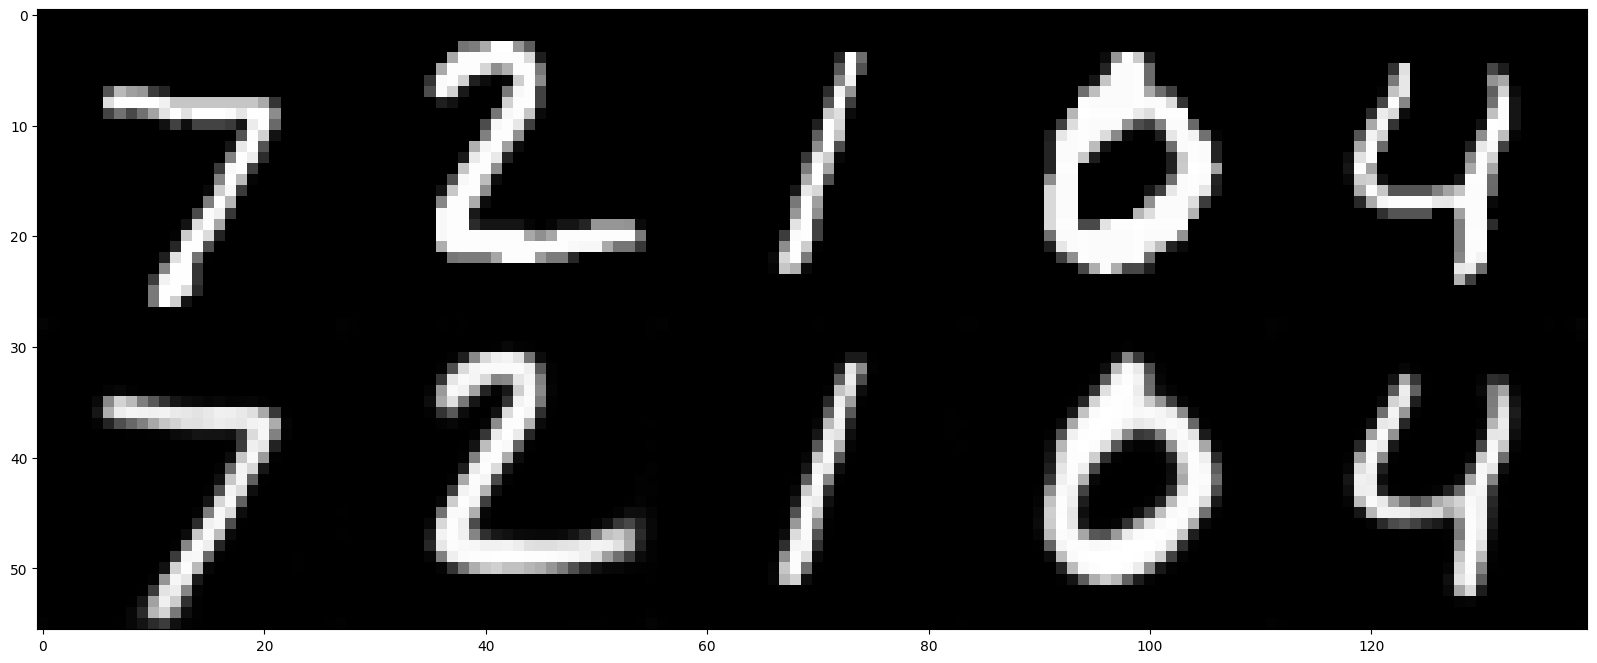

In [12]:
# visualize test data reconstructions
def vis_reconstruction(model):
  # download MNIST test set + build Dataset object
  mnist_test = torchvision.datasets.MNIST(root='./data',
                                          train=False,
                                          download=True,
                                          transform=torchvision.transforms.ToTensor())
  mnist_test_iter = iter(mnist_test)
  model.eval()      # set model in evalidation mode (eg freeze batchnorm params)
  input_imgs, test_reconstructions = [], []
  for _ in range(5):
    input_img = np.asarray(next(mnist_test_iter)[0])
    reconstruction = model.reconstruct(torch.tensor(input_img[None], device=device))
    input_imgs.append(input_img[0])
    test_reconstructions.append(reconstruction[0, 0].data.cpu().numpy())

  fig = plt.figure(figsize = (20, 50))
  ax1 = plt.subplot(111)
  ax1.imshow(np.concatenate([np.concatenate(input_imgs, axis=1),
                            np.concatenate(test_reconstructions, axis=1)], axis=0), cmap='gray')
  plt.show()

vis_reconstruction(ae_model)

## Sampling from the Auto-Encoder [2pt]

To test whether the auto-encoder is useful as a generative model, we can use it like any other generative model: draw embedding samples from a prior distribution and decode them through the decoder network. We will choose a unit Gaussian prior to allow for easy comparison to the VAE later.

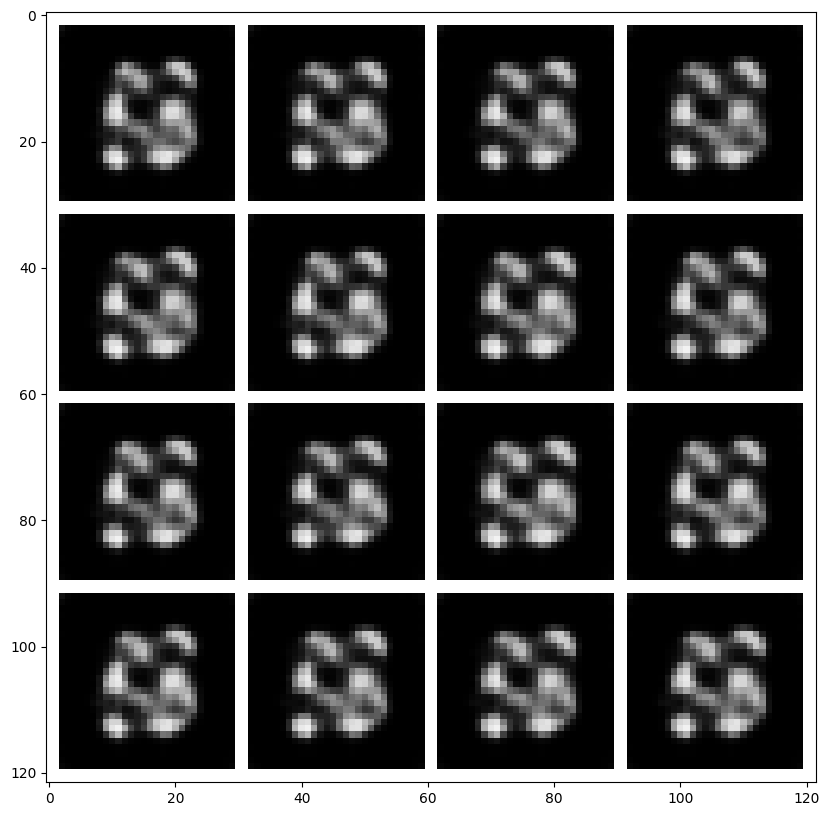

In [14]:
# we will sample N embeddings, then decode and visualize them
def vis_samples(model):
  ####################################### TODO #######################################
  # Sample embeddings from a diagonal unit Gaussian distribution and decode them     #
  # using the model.                                                                 #
  # HINT: The sampled embeddings should have shape [batch_size, nz]. Diagonal unit   #
  #       Gaussians have mean 0 and a covariance matrix with ones on the diagonal    #
  #       and zeros everywhere else.                                                 #
  # HINT: If you are unsure whether you sampled the correct distribution, you can    #
  #       sample a large batch and compute the empirical mean and variance using the #
  #       .mean() and .var() functions.                                              #
  # HINT: You can directly use model.decoder() to decode the samples.                #
  ####################################################################################
  gen = torch.Generator().manual_seed(42) # use the generator in creating your sampled embeddings!
  sampled_embeddings = None    # sample batch of embedding from prior
  decoded_samples = None       # decoder output images for sampled embeddings
  emve = torch.randn((batch_size, nz), generator=gen).to(device)
  sampled_embeddings = emve
  decoded_samples = model.decoder(sampled_embeddings)
  #################################### END TODO ######################################

  fig = plt.figure(figsize = (10, 10))
  ax1 = plt.subplot(111)
  ax1.imshow(torchvision.utils.make_grid(decoded_samples[:16], nrow=4, pad_value=1.)\
                .data.cpu().numpy().transpose(1, 2, 0), cmap='gray')
  plt.show()

vis_samples(ae_model)


>**Inline Question: Describe your observations, why do you think they occur? [2pt]** \\
>(please limit your answer to <150 words) \\
>**Answer:**
I think they occur because the latent space is unstructured and the sampling from the gaussin inputa target areas that are not proper to encode. 



# 3. Variational Auto-Encoder (VAE)

Variational auto-encoders use a very similar architecture to deterministic auto-encoders, but are inherently storchastic models, i.e. we perform a stochastic sampling operation during the forward pass, leading to different different outputs every time we run the network for the same input. This sampling is required to optimize the VAE objective also known as the evidence lower bound (ELBO):

$$
p(x) > \underbrace{\mathbb{E}_{z\sim q(z\vert x)} p(x \vert z)}_{\text{reconstruction}} - \underbrace{D_{\text{KL}}\big(q(z \vert x), p(z)\big)}_{\text{prior divergence}}
$$

Here, $D_{\text{KL}}(q, p)$ denotes the Kullback-Leibler (KL) divergence between the posterior distribution $q(z \vert x)$, i.e. the output of our encoder, and $p(z)$, the prior over the embedding variable $z$, which we can choose freely.

For simplicity, we will again choose a unit Gaussian prior. The left term is the reconstruction term we already know from training the auto-encoder. When assuming a Gaussian output distribution for both encoder $q(z \vert x)$ and decoder $p(x \vert z)$ the objective reduces to:

$$
\mathcal{L}_{\text{VAE}} = \sum_{x\sim \mathcal{D}} (x - \hat{x})^2 - \beta \cdot D_{\text{KL}}\big(\mathcal{N}(\mu_q, \sigma_q), \mathcal{N}(0, I)\big)
$$

Here, $\hat{x}$ is the reconstruction output of the decoder. In comparison to the auto-encoder objetive, the VAE adds a regularizing term between the output of the encoder and a chosen prior distribution, effectively forcing the encoder output to not stray too far from the prior during training. As a result the decoder gets trained with samples that look pretty similar to samples from the prior, which will hopefully allow us to generate better images when using the VAE as a generative model and actually feeding it samples from the prior (as we have done for the AE before).

The coefficient $\beta$ is a scalar weighting factor that trades off between reconstruction and regularization objective. We will investigate the influence of this factor in out experiments below.

If you need a refresher on VAEs you can check out this tutorial paper: https://arxiv.org/abs/1606.05908

### Reparametrization Trick

The sampling procedure inside the VAE's forward pass for obtaining a sample $z$ from the posterior distribution $q(z \vert x)$, when implemented naively, is non-differentiable. However, since $q(z\vert x)$ is parametrized with a Gaussian function, there is a simple trick to obtain a differentiable sampling operator, known as the _reparametrization trick_.

Instead of directly sampling $z \sim \mathcal{N}(\mu_q, \sigma_q)$ we can "separate" the network's predictions and the random sampling by computing the sample as:

$$
z = \mu_q + \sigma_q * \epsilon , \quad \epsilon \sim \mathcal{N}(0, I)
$$

Note that in this equation, the sample $z$ is computed as a deterministic function of the network's predictions $\mu_q$ and $\sigma_q$ and therefore allows to propagate gradients through the sampling procedure.

**Note**: While in the equations above the encoder network parametrizes the standard deviation $\sigma_q$ of the Gaussian posterior distribution, in practice we usually parametrize the **logarithm of the standard deviation** $\log \sigma_q$ for numerical stability. Before sampling $z$ we will then exponentiate the network's output to obtain $\sigma_q$.



## Defining the VAE Model [7pt]

In [30]:
def kl_divergence(mu1, log_sigma1, mu2, log_sigma2):
  """Computes KL[p||q] between two Gaussians defined by [mu, log_sigma]."""
  return (log_sigma2 - log_sigma1) + (torch.exp(log_sigma1) ** 2 + (mu1 - mu2) ** 2) \
               / (2 * torch.exp(log_sigma2) ** 2) - 0.5


class VAE(nn.Module):
  def __init__(self, nz, beta=1.0):
    super().__init__()
    self.beta = beta          # factor trading off between two loss components
    ####################################### TODO #######################################
    # Instantiate Encoder and Decoder.                                                 #
    # HINT: Remember that the encoder is now parametrizing a Gaussian distribution's   #
    #       mean and log_sigma, so the dimensionality of the output embedding needs to #
    #       double.                                                                    #
    ####################################################################################
    self.nz = nz
    self.encoder = Encoder(nz * 2)
    
    self.decoder = Decoder(nz)
    
    #################################### END TODO ######################################

  def forward(self, x):
    ####################################### TODO #######################################
    # Implement the forward pass of the VAE.                                           #
    # HINT: Your code should implement the following steps:                            #
    #          1. encode input x, split encoding into mean and log_sigma of Gaussian   #
    #          2. sample z from inferred posterior distribution using                  #
    #             reparametrization trick                                              #
    #          3. decode the sampled z to obtain the reconstructed image               #
    ####################################################################################
    # encode input into posterior distribution q(z | x)
    q = self.encoder(x)       # output of encoder (concatenated mean and log_sigma)

    # sample latent variable z with reparametrization
    mu, log_sigma = q[:, :self.nz], q[:, self.nz:]
    z = mu + torch.exp(log_sigma) * torch.randn_like(mu)  # batch of sampled embeddings

    # compute reconstruction
    reconstruction = self.decoder(z)   # decoder reconstruction from embedding
    #################################### END TODO ######################################

    return {'q': q,
            'rec': reconstruction}

  def loss(self, x, outputs):
    ####################################### TODO #######################################
    # Implement the loss computation of the VAE.                                       #
    # HINT: Your code should implement the following steps:                            #
    #          1. compute the image reconstruction loss, similar to AE we use MSE loss #
    #          2. compute the KL divergence loss between the inferred posterior        #
    #             distribution and a unit Gaussian prior; you can use the provided     #
    #             function above for computing the KL divergence between two Gaussians #
    #             parametrized by mean and log_sigma                                   #
    # HINT: Make sure to compute the KL divergence in the correct order since it is    #
    #       not symmetric, ie. KL(p, q) != KL(q, p)!                                   #
    ####################################################################################
    # compute reconstruction loss
    rec_loss = nn.MSELoss()(outputs['rec'], x)
    q = outputs['q']
    mu, log_sigma = q[:, :self.nz], q[:, self.nz:]
    # compute KL divergence loss
    kl_loss = kl_divergence(mu, log_sigma, torch.zeros_like(mu), torch.zeros_like(log_sigma)).mean()  # make sure that this is a scalar, not a vector / array
    #################################### END TODO ######################################

    # return weighted objective
    return rec_loss + self.beta * kl_loss, \
           {'rec_loss': rec_loss, 'kl_loss': kl_loss}

  def reconstruct(self, x):
    """Use mean of posterior estimate for visualization reconstruction."""
    ####################################### TODO #######################################
    # This function is used for visualizing reconstructions of our VAE model. To       #
    # obtain the maximum likelihood estimate we bypass the sampling procedure of the   #
    # inferred latent and instead directly use the mean of the inferred posterior.     #
    # HINT: encode the input image and then decode the mean of the posterior to obtain #
    #       the reconstruction.                                                        #
    ####################################################################################
    reconstruction = self.decoder(self.encoder(x)[:, :self.nz])   # decoder reconstruction from embedding
    #################################### END TODO ######################################
    return reconstruction


## Setting up the VAE Training Loop [4pt]

Let's start training the VAE model! We will first verify our implementation by setting $\beta = 0$.


First, let's start by defining a function that we can use to try different $\beta$ values.  You'll reuse this code later in the assignment!

In [31]:
def run_with_beta(epochs, learning_rate, beta):
  # build VAE model
  vae_model = VAE(nz, beta).to(device)    # transfer model to GPU if available
  vae_model = vae_model.train()   # set model in train mode (eg batchnorm params get updated)

  # build optimizer and loss function
  ####################################### TODO #######################################
  # Build the optimizer for the vae_model. We will again use the Adam optimizer with #
  # the given learning rate and otherwise default parameters.                        #
  ####################################################################################
  opt = None
  beta = beta
  opt = torch.optim.Adam(vae_model.parameters(), learning_rate)
  #################################### END TODO ######################################

  train_it = 0
  rec_loss, kl_loss = [], []
  for ep in range(epochs):
    print("Run Epoch {}".format(ep))
    ####################################### TODO #######################################
    # Implement the main training loop for the VAE model.                              #
    # HINT: Your training loop should sample batches from the data loader, run the     #
    #       forward pass of the VAE, compute the loss, perform the backward pass and   #
    #       perform one gradient step with the optimizer.                              #
    # HINT: Don't forget to erase old gradients before performing the backward pass.   #
    # HINT: This time we will use the loss() function of our model for computing the   #
    #       training loss. It outputs the total training loss and a dict containing    #
    #       the breakdown of reconstruction and KL loss.                               #
    ####################################################################################
    vae_model.train()
    for batch_imgs, batch_labels in mnist_data_loader:
        batch_imgs = batch_imgs.to(device)
        opt.zero_grad()
        outputs = vae_model(batch_imgs)
        total_loss, losses = vae_model.loss(batch_imgs, outputs)
        total_loss.backward()
        opt.step()
    
        # ...
        #################################### END TODO ####################################

        rec_loss.append(losses['rec_loss'].item()); kl_loss.append(losses['kl_loss'].item())
        if train_it % 100 == 0:
          print("It {}: Total Loss: {}, \t Rec Loss: {},\t KL Loss: {}"\
                .format(train_it, total_loss, losses['rec_loss'], losses['kl_loss']))
        train_it += 1

  print("Done!")

  # log the loss training curves
  fig = plt.figure(figsize = (10, 5))
  ax1 = plt.subplot(121)
  ax1.plot(rec_loss)
  ax1.title.set_text("Reconstruction Loss")
  ax2 = plt.subplot(122)
  ax2.plot(kl_loss)
  ax2.title.set_text("KL Loss")
  plt.show()

  return vae_model

Now, let's run that code with $\beta=0$!

Run Epoch 0
It 0: Total Loss: 3.175462245941162, 	 Rec Loss: 0.20535361766815186,	 KL Loss: 0.2970108687877655
It 100: Total Loss: 0.07759878784418106, 	 Rec Loss: 0.06685391813516617,	 KL Loss: 0.0010744868777692318
It 200: Total Loss: 0.07172412425279617, 	 Rec Loss: 0.06712333112955093,	 KL Loss: 0.00046007963828742504
It 300: Total Loss: 0.07180237770080566, 	 Rec Loss: 0.06929214298725128,	 KL Loss: 0.00025102338986471295
It 400: Total Loss: 0.06647448986768723, 	 Rec Loss: 0.06473825871944427,	 KL Loss: 0.0001736231497488916
It 500: Total Loss: 0.0691782757639885, 	 Rec Loss: 0.06783277541399002,	 KL Loss: 0.0001345501805189997
It 600: Total Loss: 0.063886359333992, 	 Rec Loss: 0.06281726807355881,	 KL Loss: 0.00010690908675314859
It 700: Total Loss: 0.0652494803071022, 	 Rec Loss: 0.06426869332790375,	 KL Loss: 9.807861351873726e-05
It 800: Total Loss: 0.0711694210767746, 	 Rec Loss: 0.07006309181451797,	 KL Loss: 0.00011063255078624934
It 900: Total Loss: 0.06568776071071625, 	

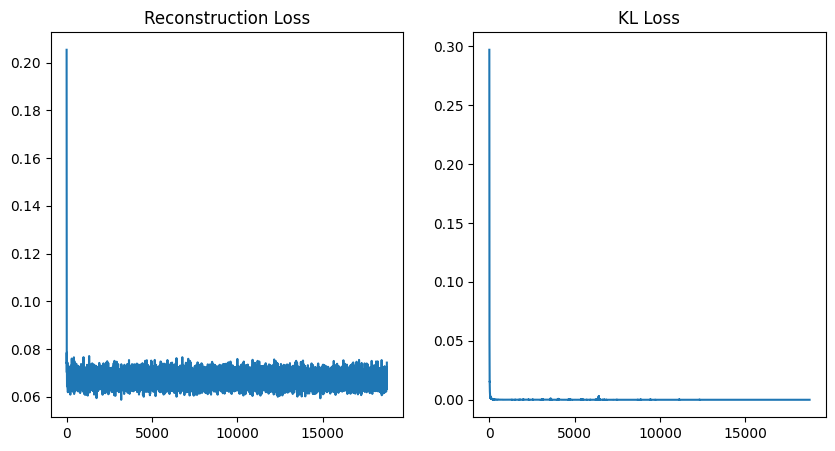

In [37]:
learning_rate = 1.5e-3
nz = 64

####################################### TODO #######################################
# Tune the beta parameter to obtain good VAE training results. However, for the    #
# initial experiments leave beta = 0 in order to verify our implementation.        #
####################################################################################
epochs = 20         # using 5 epochs is sufficient for the first two experiments
                   # for the experiment where you tune beta, 20 epochs are appropriate
beta = 10.0
#################################### END TODO ######################################

vae_model = run_with_beta(epochs=epochs, learning_rate=learning_rate, beta=beta)

Let's look at some reconstructions and decoded embedding samples!

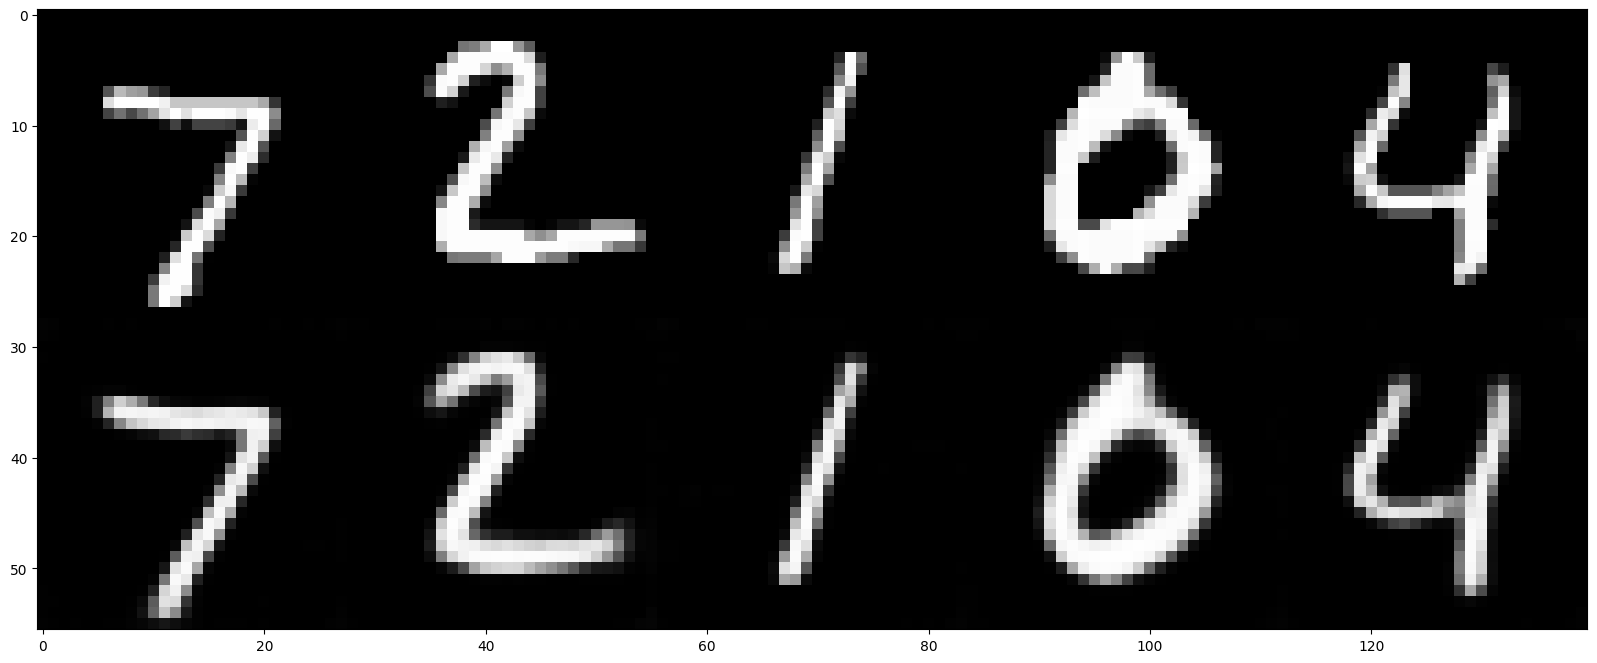

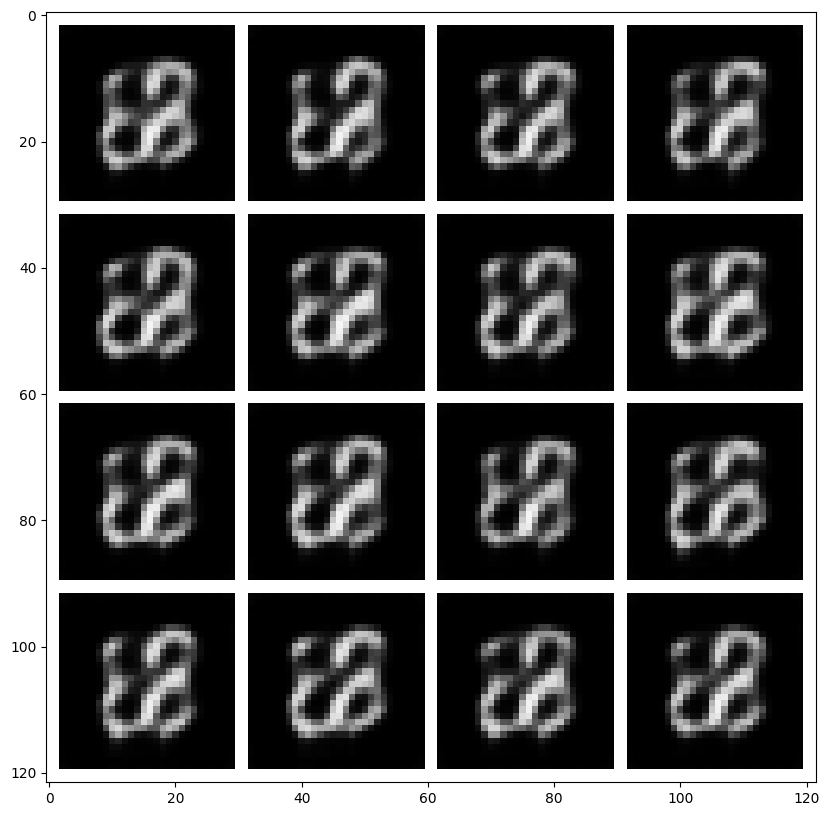

In [33]:
# visualize VAE reconstructions and samples from the generative model
vis_reconstruction(vae_model)
vis_samples(vae_model)

>**Inline Question: What can you observe when setting $\beta = 0$? Explain your observations! [3pt]** \\
>(please limit your answer to <150 words) \\
>**Answer:**
I observe an almost identical reconstruction of the image and because beta is 0 the KL in nulled and therefore performs like a standard encoder. 

Let's repeat the same experiment for $\beta = 10$, a very high value for the coefficient. You can modify the $\beta$ value in the cell above and rerun it (it is okay to overwrite the outputs of the previous experiment, but **make sure to copy the visualizations of training curves, reconstructions and samples for $\beta = 0$ into your solution PDF** before deleting them).

>**Inline Question: What can you observe when setting $\beta = 10$? Explain your observations! [3pt]** \\
>(please limit your answer to <200 words) \\
>**Answer**:
What I obersve for this result when the epochs are 20 and beta is 10 si a more clear and concise image. Albeit, reconstruction loss oscillates much higher in range from 0.60 to 0.80. 

Run Epoch 0
It 0: Total Loss: 0.31407299637794495, 	 Rec Loss: 0.28463831543922424,	 KL Loss: 0.29434677958488464
It 100: Total Loss: 0.06674179434776306, 	 Rec Loss: 0.0644521489739418,	 KL Loss: 0.02289646863937378
It 200: Total Loss: 0.06774162501096725, 	 Rec Loss: 0.06420018523931503,	 KL Loss: 0.03541441261768341
It 300: Total Loss: 0.05862218886613846, 	 Rec Loss: 0.052929703146219254,	 KL Loss: 0.056924838572740555
It 400: Total Loss: 0.06021967902779579, 	 Rec Loss: 0.05314811319112778,	 KL Loss: 0.07071566581726074
It 500: Total Loss: 0.05241142958402634, 	 Rec Loss: 0.0435006283223629,	 KL Loss: 0.08910800516605377
It 600: Total Loss: 0.04909569025039673, 	 Rec Loss: 0.04000040143728256,	 KL Loss: 0.09095288813114166
It 700: Total Loss: 0.04784386605024338, 	 Rec Loss: 0.0378439761698246,	 KL Loss: 0.09999890625476837
It 800: Total Loss: 0.04739448055624962, 	 Rec Loss: 0.037090182304382324,	 KL Loss: 0.10304297506809235
It 900: Total Loss: 0.0454251654446125, 	 Rec Loss: 0.

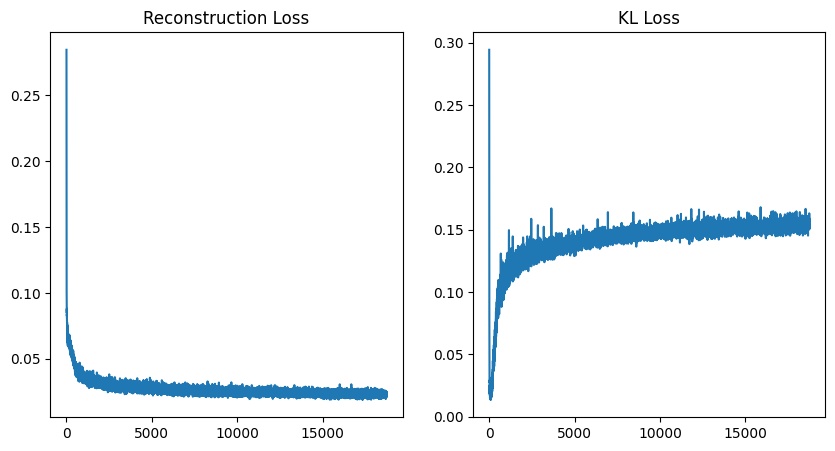

In [42]:
learning_rate = 1.5e-3
nz = 64

####################################### TODO #######################################
# Tune the beta parameter to obtain good VAE training results. However, for the    #
# initial experiments leave beta = 0 in order to verify our implementation.        #
####################################################################################
epochs = 20         # using 5 epochs is sufficient for the first two experiments
                   # for the experiment where you tune beta, 20 epochs are appropriate
beta = 0.1             # HINT: Set your beta to 10 here, and see what happens!
#################################### END TODO ######################################

vae_model = run_with_beta(epochs=epochs, learning_rate=learning_rate, beta=beta)

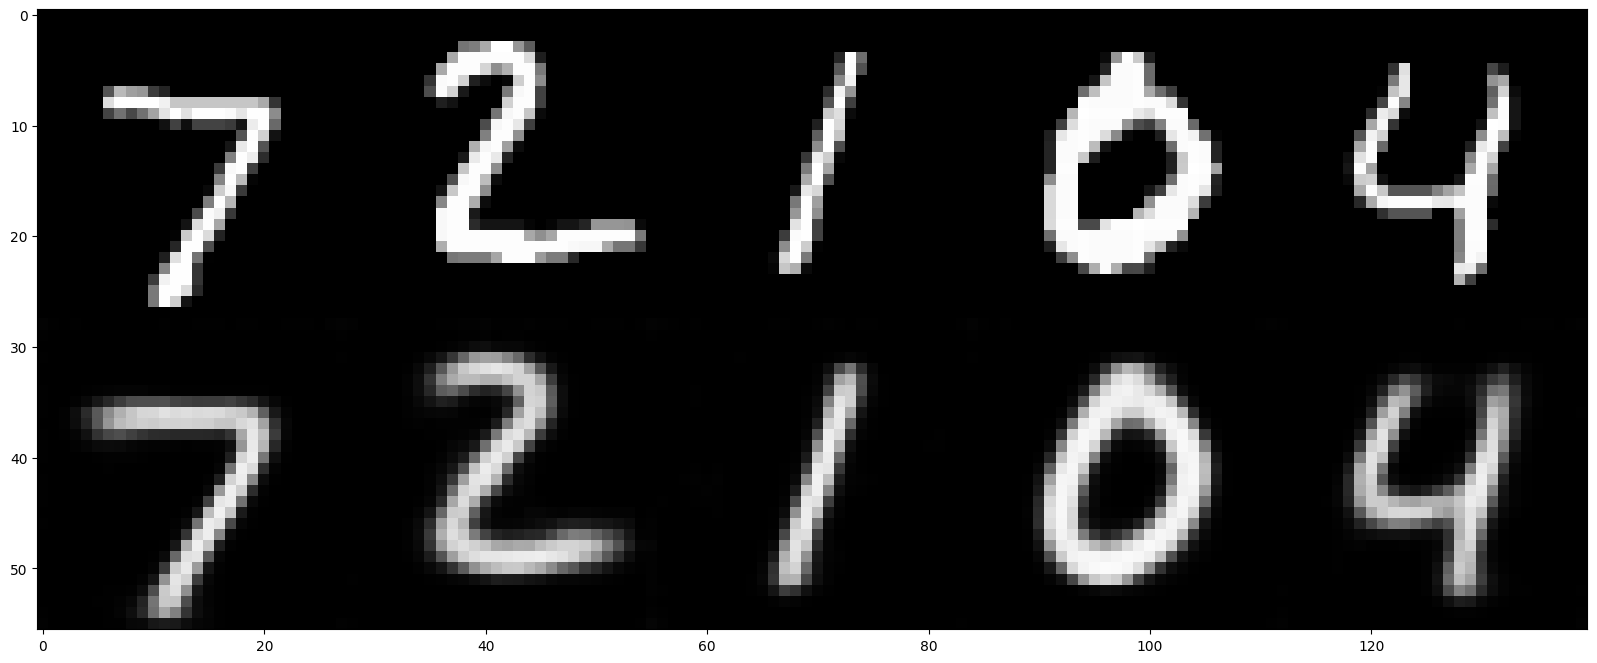

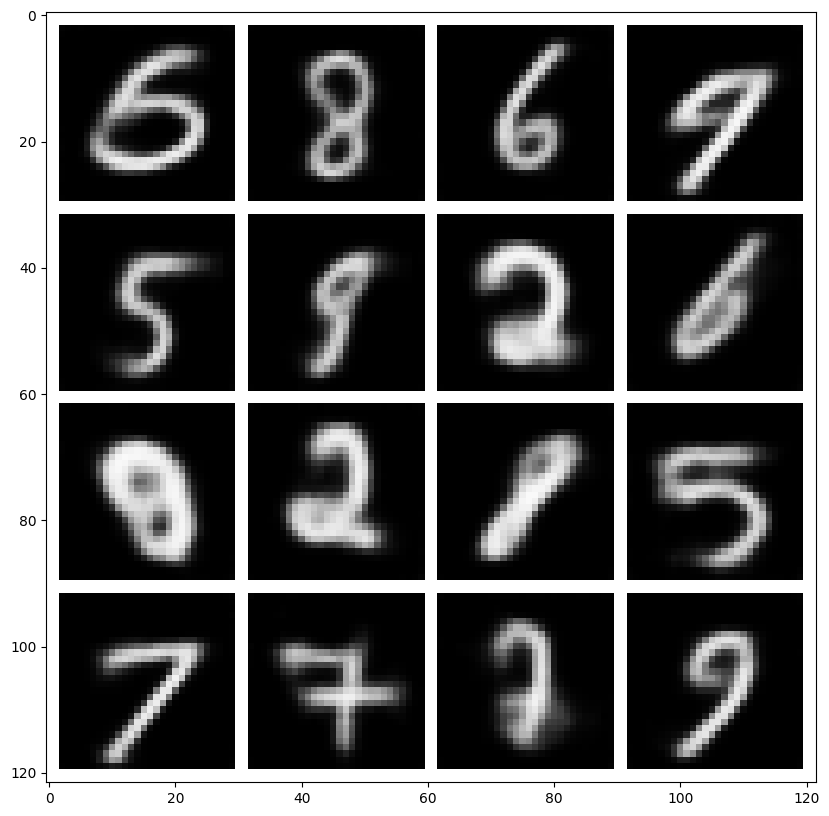

In [43]:
# visualize VAE reconstructions and samples from the generative model
vis_reconstruction(vae_model)
vis_samples(vae_model)

Now we can start tuning the beta value to achieve a good result. First describe what a "good result" would look like (focus what you would expect for reconstructions and sample quality).

>**Inline Question: Characterize what properties you would expect for reconstructions (1pt) and samples (2pt) of a well-tuned VAE! [3pt]** \\
>(please limit your answer to <200 words) \\
>**Answer**:
What I would characterize for reconstruction is about similar posterior collapse and nullifying encoding information. With beta being lower at just the right spot there can be meaningful reconstruction and sample encoding from gaussian. While the higher it goes (beta) there can be more latent space match, but less meaningful gaussian sampling. 

## Tuning the $\beta$-factor [5pt]
Now that you know what outcome we would like to obtain, try to tune $\beta$ to achieve this result.

(logarithmic search in steps of 10x will be helpful, good results can be achieved after ~20 epochs of training). It is again okay to overwrite the results of the previous $\beta=10$ experiment after copying them to the solution PDF.

**Your final notebook should include the visualizations of your best-tuned VAE.**


Run Epoch 0
It 0: Total Loss: 0.3195957541465759, 	 Rec Loss: 0.2907479405403137,	 KL Loss: 0.2884781062602997
It 100: Total Loss: 0.07092412561178207, 	 Rec Loss: 0.06908167898654938,	 KL Loss: 0.01842447929084301
It 200: Total Loss: 0.06331250816583633, 	 Rec Loss: 0.058648038655519485,	 KL Loss: 0.04664469510316849
It 300: Total Loss: 0.05766134709119797, 	 Rec Loss: 0.05175628885626793,	 KL Loss: 0.05905056372284889
It 400: Total Loss: 0.05878666788339615, 	 Rec Loss: 0.05153428763151169,	 KL Loss: 0.07252378761768341
It 500: Total Loss: 0.05636210739612579, 	 Rec Loss: 0.04772089049220085,	 KL Loss: 0.08641214668750763
It 600: Total Loss: 0.054063573479652405, 	 Rec Loss: 0.044148657470941544,	 KL Loss: 0.09914916753768921
It 700: Total Loss: 0.04734276607632637, 	 Rec Loss: 0.037575863301754,	 KL Loss: 0.09766902774572372
It 800: Total Loss: 0.04974311590194702, 	 Rec Loss: 0.039067625999450684,	 KL Loss: 0.10675489902496338
It 900: Total Loss: 0.048855602741241455, 	 Rec Loss: 0

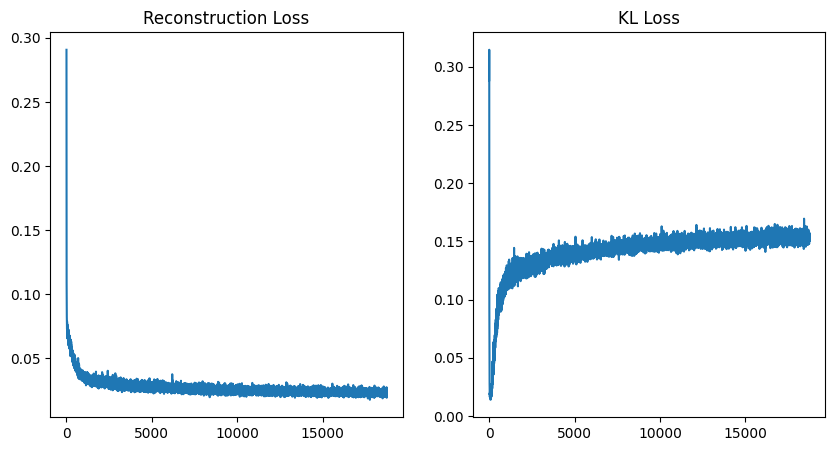

In [44]:
learning_rate = 1.5e-3
nz = 64

####################################### TODO #######################################
# Tune the beta parameter to obtain good VAE training results. However, for the    #
# initial experiments leave beta = 0 in order to verify our implementation.        #
####################################################################################
epochs =20            # <--- Set your epochs here!
                   # for the experiment where you tune beta, 20 epochs are appropriate
beta =0.1             # <--- Try different values of beta here!
#################################### END TODO ######################################

vae_model = run_with_beta(epochs=epochs, learning_rate=learning_rate, beta=beta)

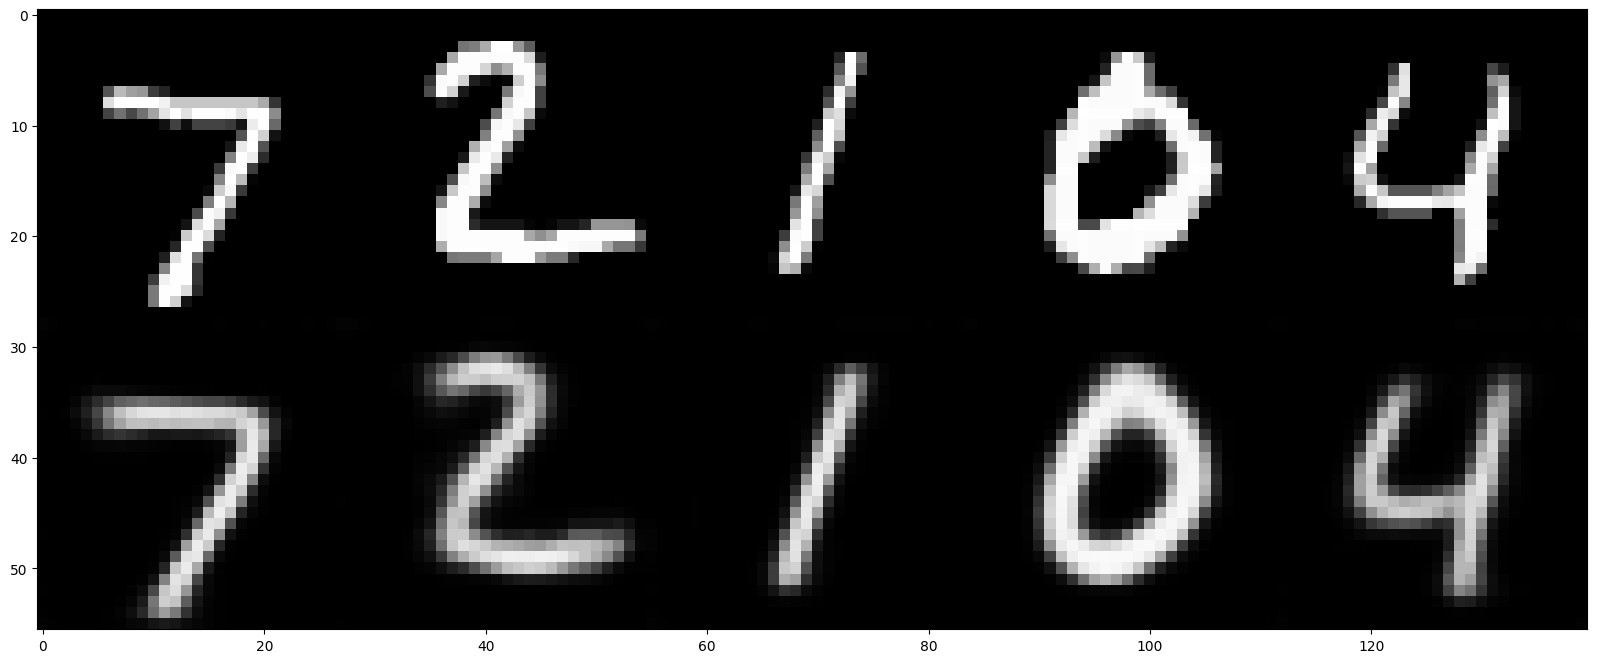

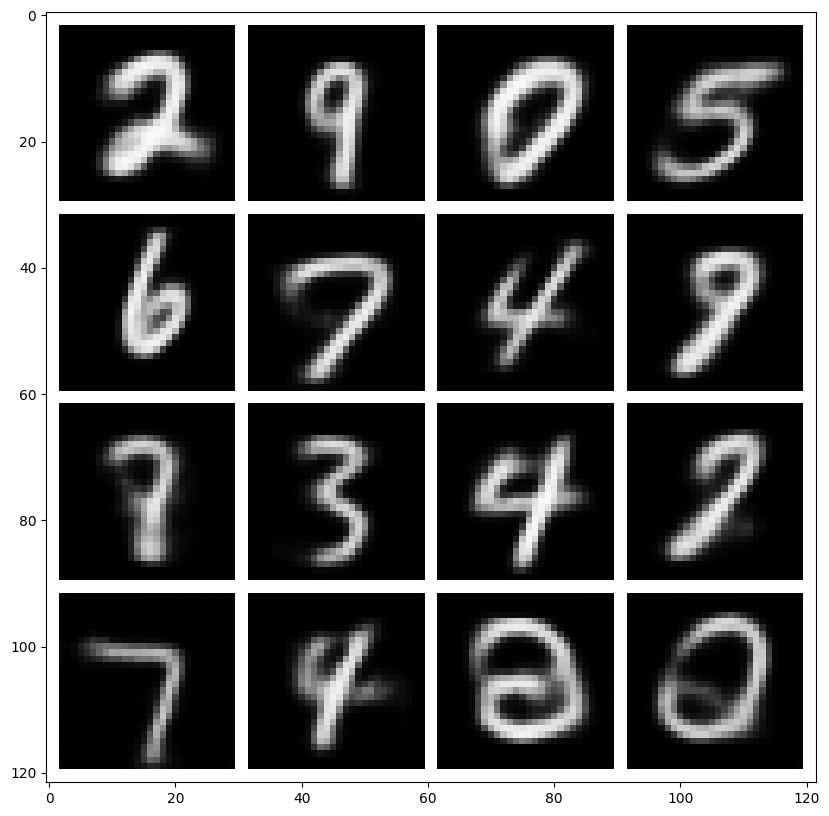

In [45]:
# visualize VAE reconstructions and samples from the generative model
vis_reconstruction(vae_model)
vis_samples(vae_model)

# 4. Embedding Space Interpolation [3pt]

As mentioned in the introduction, AEs and VAEs cannot only be used to generate images, but also to learn low-dimensional representations of their inputs. In this final section we will investigate the representations we learned with both models by **interpolating in embedding space** between different images. We will encode two images into their low-dimensional embedding representations, then interpolate these embeddings and reconstruct the result.

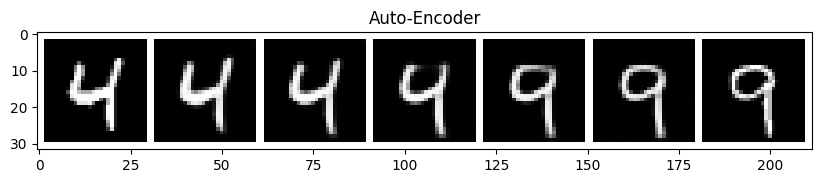

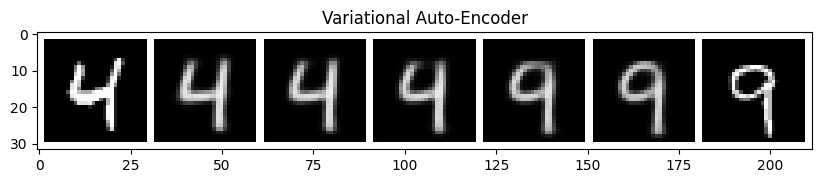

In [51]:
START_LABEL = 4
END_LABEL = 9
nz=64

def get_image_with_label(target_label):
  """Returns a random image from the training set with the requested digit."""
  for img_batch, label_batch in mnist_data_loader:
    for img, label in zip(img_batch, label_batch):
      if label == target_label:
        return img.to(device)

def interpolate_and_visualize(model, tag, start_img, end_img):
  """Encodes images and performs interpolation. Displays decodings."""
  model.eval()    # put model in eval mode to avoid updating batchnorm

  # encode both images into embeddings (use posterior mean for interpolation)
  z_start = model.encoder(start_img[None])[..., :nz]
  z_end = model.encoder(end_img[None])[..., :nz]

  # compute interpolated latents
  N_INTER_STEPS = 5
  z_inter = [z_start + i/N_INTER_STEPS * (z_end - z_start) for i in range(N_INTER_STEPS)]

  # decode interpolated embeddings (as a single batch)
  img_inter = model.decoder(torch.cat(z_inter))

  # reshape result and display interpolation
  vis_imgs = torch.cat([start_img[None], img_inter, end_img[None]])
  fig = plt.figure(figsize = (10, 10))
  ax1 = plt.subplot(111)
  ax1.imshow(torchvision.utils.make_grid(vis_imgs, nrow=N_INTER_STEPS+2, pad_value=1.)\
                  .data.cpu().numpy().transpose(1, 2, 0), cmap='gray')
  plt.title(tag)
  plt.show()


# sample two training images with given labels
start_img = get_image_with_label(START_LABEL)
end_img = get_image_with_label(END_LABEL)

# visualize interpolations for AE and VAE models
interpolate_and_visualize(ae_model, "Auto-Encoder", start_img, end_img)
interpolate_and_visualize(vae_model, "Variational Auto-Encoder", start_img, end_img)


Repeat the experiment for different start / end labels and different samples. Describe your observations.

>**Inline Question: Repeat the interpolation experiment with different start / end labels and multiple samples. Describe your observations!
Focus on**: \\
  1. **How do AE and VAE embedding space interpolations differ?** \\
  2. **How do you expect these differences to affect the usefulness of the learned representation for downstream learning?** \\
(please limit your answer to <300 words)

>**Answer**: 
1. Both AE and VAE transition fairly smoothly, but the AE seems to abruptly change or alter to transition, while the VAE keeps a more stable and gradual transition.
2. VAE is more useful when it comes to classification and the AE is more useful when it comes to encoding specifically geometric spatial boundaries. 

# Submission PDF

Please prepare a separate submission PDF for each problem. For this problem, please include the following plots & answers in a PDF called `problem_1_solution.pdf`:

1. Auto-encoder samples and AE sampling inline question answer.
2. VAE training curves, reconstructions and samples for:
  * $\beta = 0$
  * $\beta = 10$
  * your tuned $\beta$ (also listing the tuned value for $\beta$)
3. Answers to all inline questions in VAE section (ie 4 inline questions).
4. Three representative interpolation comparisons that show AE and VAE embedding interpolation between the same images.
5. Answer to interpolation inline question.

Note that you still need to submit the jupyter notebook with all generated solutions. We will randomly pick submissions and check that the plots in the PDF and in the notebook are equivalent (except for those $\beta=0\;/\;10$ plots that we allowed to overwrite).